# Univariate Analysis

I am utilizing the following variables as downscaling variables and/or predictors: 

T2: Temperature (at 2m above ground)
* used as a predictor or as the downscaling variable of interest
    
PSFC: Surface Pressure
*  used as a predictor
    
U10: U-component of wind (at 10m above ground)
* used as a predictor or as the downscaling variable of interest
    
V10: V-compoennet of wind (at 10m above ground)
* used as a predictor or as the downscaling variable of interest
    
SWDOWN: Global Horizontal Irradiance
* used as a predictor or as the downscaling variable of interest
    
sin_time: 

cos_time:

PBLH: Planetary Boundary Height

In [1]:
import seaborn as sns

In [2]:
import xarray as xr
uwrf_train = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_train.nc')
uwrf_val = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_val.nc')
uwrf_test = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_test.nc')
# --------
nam_train = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_train.nc')
nam_val = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_val.nc')
nam_test = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_test.nc')

In [3]:
# Choose the variable you would like to examine:

choices = ['T2', 'PSFC', 'U10', 'V10', 'SWDOWN', 'PBLH']

datasets = ['uwrf', 'nam']


# Change the following cell according to the variable and dataset you would like to examine

In [4]:
#Change var and df based on your preference
var = 'V10' 
df = 'uwrf'

if df == 'uwrf':
    data = uwrf_train
    ds = data[var]
elif df == 'nam':
    data = nam_train
    ds = data[var]
else:
    raise ValueError(f"Invalid string: '{df}'. Expected either 'uwrf' or 'nam'.")

In [5]:
data

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 2697, y: 120, x: 120)
Coordinates:
    latitude   (time, y, x) float32 155MB ...
    longitude  (time, y, x) float32 155MB ...
  * time       (time) datetime64[ns] 22kB 2019-01-01 ... 2019-04-14T03:00:00
Dimensions without coordinates: y, x
Data variables:
    T2         (time, y, x) float32 155MB ...
    PSFC       (time, y, x) float32 155MB ...
    U10        (time, y, x) float32 155MB ...
    V10        (time, y, x) float32 155MB ...
    SWDOWN     (time, y, x) float32 155MB ...
    PBLH       (time, y, x) float32 155MB ...
    HGT        (time, y, x) float32 155MB ...
Attributes: (12/119)
    TITLE:                            OUTPUT FROM WRF V3.9 MODEL
    START_DATE:                      2019-01-01_00:00:00
    SIMULATION_START_DATE:           2019-01-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        121
    SOUTH-NORTH_GRID_DIMENSION:      121
    BOTTOM-TOP_GRID_DIMENSION:       51
    ...                              ...
    ISLAKE:                          -1
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      -1
    ETAC:                            0.0

In [6]:
ds

<xarray.DataArray 'V10' (time: 2697, y: 120, x: 120)> Size: 155MB
[38836800 values with dtype=float32]
Coordinates:
    latitude   (time, y, x) float32 155MB ...
    longitude  (time, y, x) float32 155MB ...
  * time       (time) datetime64[ns] 22kB 2019-01-01 ... 2019-04-14T03:00:00
Dimensions without coordinates: y, x
Attributes:
    FieldType:    104
    MemoryOrder:  XY 
    description:  V at 10 M
    units:        m s-1
    stagger:

In [7]:
print(ds)

<xarray.DataArray 'V10' (time: 2697, y: 120, x: 120)> Size: 155MB
[38836800 values with dtype=float32]
Coordinates:
    latitude   (time, y, x) float32 155MB ...
    longitude  (time, y, x) float32 155MB ...
  * time       (time) datetime64[ns] 22kB 2019-01-01 ... 2019-04-14T03:00:00
Dimensions without coordinates: y, x
Attributes:
    FieldType:    104
    MemoryOrder:  XY 
    description:  V at 10 M
    units:        m s-1
    stagger:      


In [8]:
print(ds['latitude'].shape)
print(ds['longitude'].shape)

(2697, 120, 120)
(2697, 120, 120)


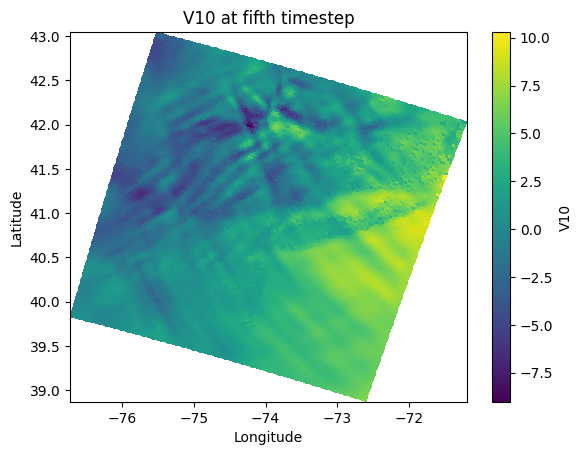

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.pcolormesh(ds.longitude.isel(time=5), ds.latitude.isel(time=5), ds.isel(time=5), shading='auto')
plt.title(f'{var} at fifth timestep')
plt.colorbar(label=f'{var}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


# Fix Warped Grid Later

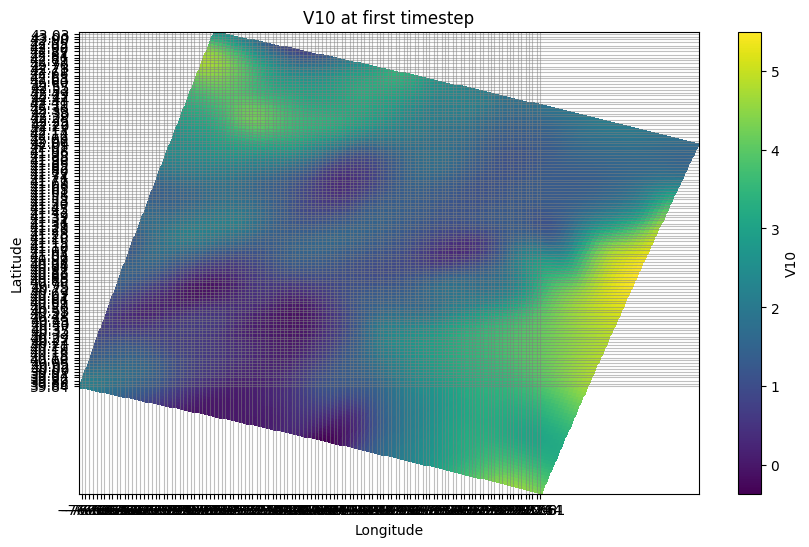

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Select the first time step to examine the grid
lat = ds.latitude.isel(time=0).values
lon = ds.longitude.isel(time=0).values
f = ds.isel(time=0).values

plt.figure(figsize=(10,6))
mesh = plt.pcolormesh(lon, lat, f, shading='auto')
plt.title(f'{var} at first timestep')
plt.colorbar(mesh, label=f'{var}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# If grid is regular, set major ticks at each coordinate
plt.xticks(np.round(lon[0, :], 2))
plt.yticks(np.round(lat[:, 0], 2))
plt.grid(True, linestyle='-', color='gray', alpha=0.5)

plt.show()

In [13]:
lat = ds.latitude.isel(time=0).values
lon = ds.longitude.isel(time=0).values

# Check if lat/lon vary only in one direction
print("Is latitude regular across y?", np.allclose(lat, lat[:, 0][:, None]))
print("Is longitude regular across x?", np.allclose(lon, lon[0, :][None, :]))


Is latitude regular across y? False
Is longitude regular across x? False


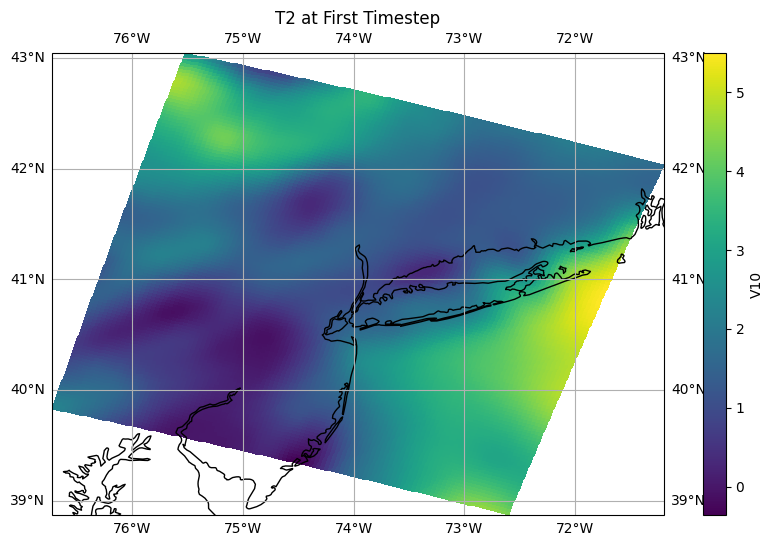

In [14]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})

mesh = ax.pcolormesh(
    ds.longitude.isel(time=0),
    ds.latitude.isel(time=0),
    ds.isel(time=0),
    transform=ccrs.PlateCarree(),
    shading='auto'
)

ax.coastlines()
ax.gridlines(draw_labels=True)
plt.colorbar(mesh, ax=ax, label=f'{var}')
plt.title('T2 at First Timestep')
plt.show()


# Understanding the Time Dmension

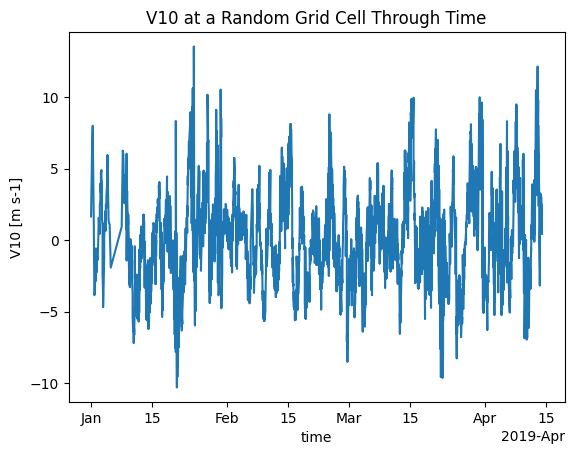

In [15]:
x = 10
y = 10

series = ds.sel(x=x, y=y)
series.plot()

plt.ylim(float(series.min()) - 1, float(series.max()) + 1)
plt.title(f'{var} at a Random Grid Cell Through Time')
plt.show()

# Average over time

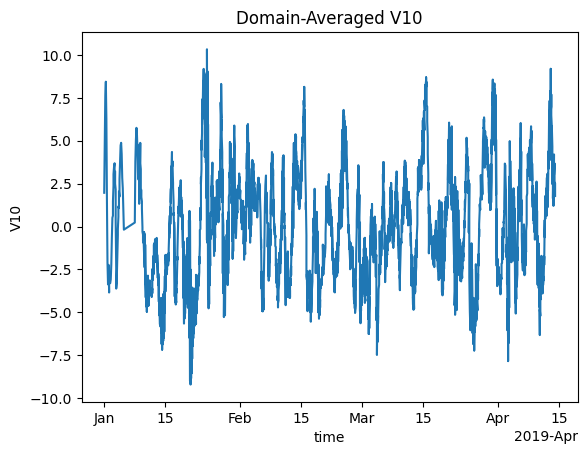

In [13]:
series = ds.mean(dim=['x', 'y'])
series.plot()
plt.ylim(float(series.min()) - 1, float(series.max()) + 1)
plt.title(f'Domain-Averaged {var}')
plt.show()

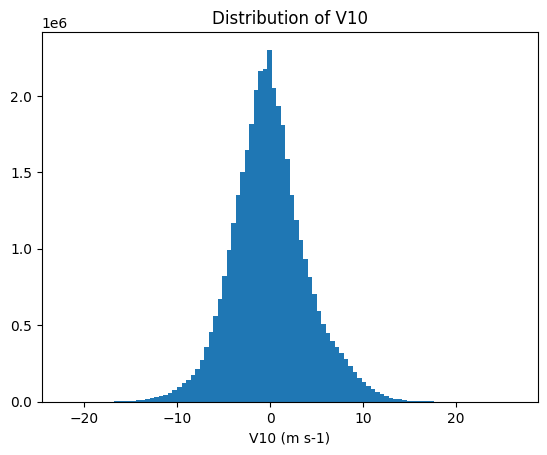

In [14]:
vals = ds.values.flatten()
plt.hist(vals, bins=100)
plt.title(f'Distribution of {var}')
plt.xlabel(f'{var} ({ds.units})')
plt.show()

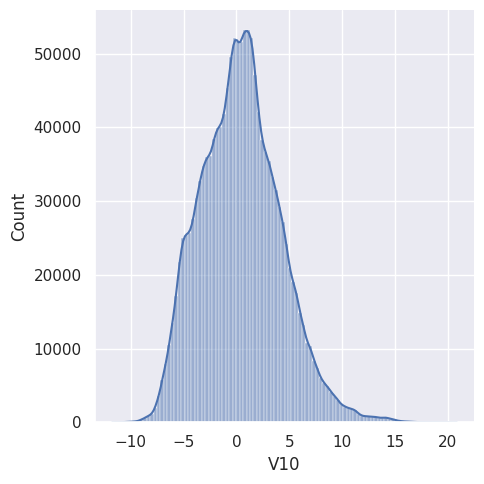

In [37]:
import pandas as pd
sns.set_theme()
flat = ds.isel(time=slice(0, 100)).values.flatten()
df = pd.DataFrame({'V10': flat})
sns.displot(data=df, x="V10", bins=100, kde=True)

In [15]:
import pandas as pd

variables = ['T2', 'PSFC', 'U10', 'V10', 'SWDOWN', 'PBLH']

stats = []

for var in variables:
    df = data[var].values.flatten()
    df = df[~np.isnan(df)] #Removing NaNs

    stats.append({
    'Variable': f'{var} ({data[var].units})',
    'Mean': np.mean(df),
    'Std': np.std(df),
    'Min': np.min(df),
    'Max': np.max(df),
    'Skew': pd.Series(df).skew()
    })
                 
df_stats = pd.DataFrame(stats)

df_stats.round(2)
print(df_stats)

         Variable           Mean          Std           Min            Max  \
0          T2 (K)     273.091492     6.900066    237.515167     300.812378   
1       PSFC (Pa)  100012.257812  2445.371338  89075.156250  104270.335938   
2     U10 (m s-1)       1.990458     4.897593    -22.684288      26.586498   
3     V10 (m s-1)      -0.051780     4.051602    -22.152691      26.383493   
4  SWDOWN (W m-2)     108.661491   206.712646      0.000000     919.448425   
5        PBLH (m)     553.515503   494.761536      0.000000    6881.676758   

       Skew  
0 -0.301742  
1 -0.828836  
2  0.262704  
3  0.234389  
4  1.987271  
5  1.109548  


In [16]:
uwrf = uwrf_train['U10']

In [17]:
nam = nam_train['U10']

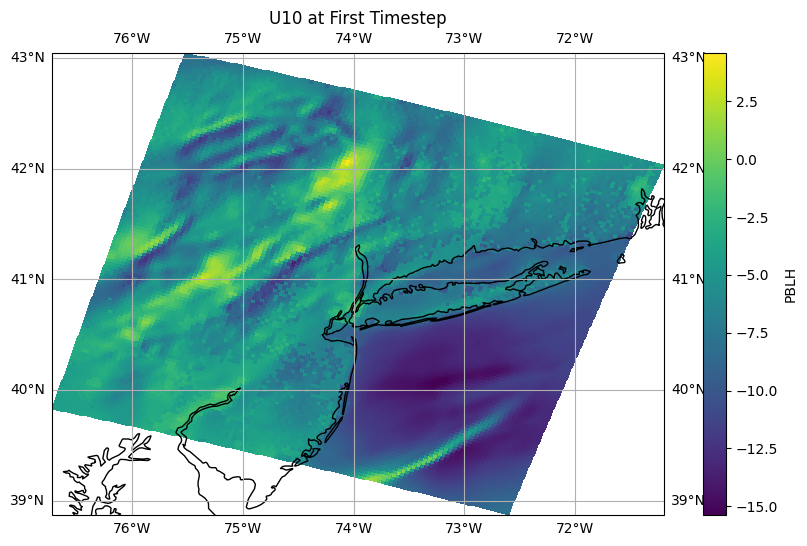

In [18]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})

mesh = ax.pcolormesh(
    uwrf.longitude.isel(time=0),
    uwrf.latitude.isel(time=0),
    uwrf.isel(time=1),
    transform=ccrs.PlateCarree(),
    shading='auto'
)

ax.coastlines()
ax.gridlines(draw_labels=True)
plt.colorbar(mesh, ax=ax, label=f'{var}')
plt.title('U10 at First Timestep')
plt.show()


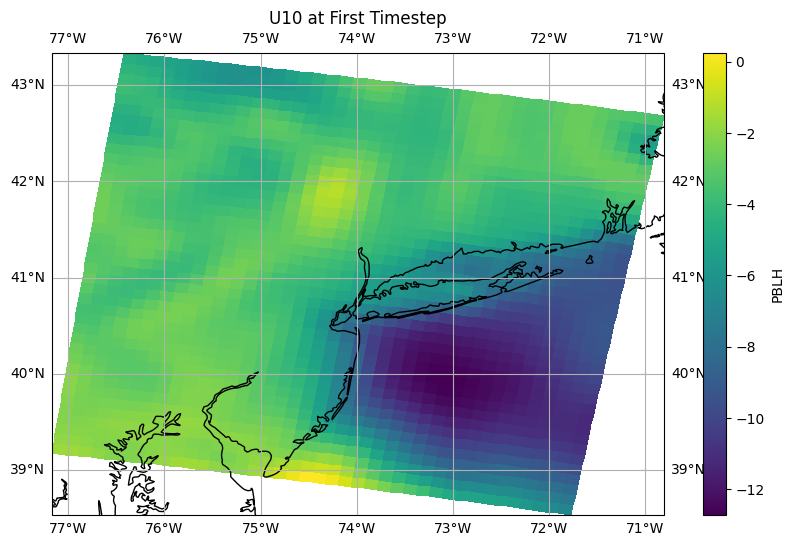

In [19]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})

mesh = ax.pcolormesh(
    nam.longitude,
    nam.latitude,
    nam.isel(time=1),
    transform=ccrs.PlateCarree(),
    shading='auto'
)

ax.coastlines()
ax.gridlines(draw_labels=True)
plt.colorbar(mesh, ax=ax, label=f'{var}')
plt.title('U10 at First Timestep')
plt.show()


In [20]:
uwrf_test

<xarray.Dataset> Size: 300MB
Dimensions:    (time: 578, y: 120, x: 120)
Coordinates:
    latitude   (time, y, x) float32 33MB ...
    longitude  (time, y, x) float32 33MB ...
  * time       (time) datetime64[ns] 5kB 2019-05-04T21:00:00 ... 2019-05-29T1...
Dimensions without coordinates: y, x
Data variables:
    T2         (time, y, x) float32 33MB ...
    PSFC       (time, y, x) float32 33MB ...
    U10        (time, y, x) float32 33MB ...
    V10        (time, y, x) float32 33MB ...
    SWDOWN     (time, y, x) float32 33MB ...
    PBLH       (time, y, x) float32 33MB ...
    HGT        (time, y, x) float32 33MB ...
Attributes: (12/119)
    TITLE:                            OUTPUT FROM WRF V3.9 MODEL
    START_DATE:                      2019-01-01_00:00:00
    SIMULATION_START_DATE:           2019-01-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        121
    SOUTH-NORTH_GRID_DIMENSION:      121
    BOTTOM-TOP_GRID_DIMENSION:       51
    ...                              ...
    ISLAKE:                          -1
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      -1
    ETAC:                            0.0

In [21]:
nam_test.T2.isel(time=1)

<xarray.DataArray 'T2' (y: 40, x: 40)> Size: 6kB
[1600 values with dtype=float32]
Coordinates:
  * y          (y) float64 320B 1.219e+04 2.438e+04 ... 4.754e+05 4.876e+05
  * x          (x) float64 320B 3.292e+05 3.413e+05 ... 7.924e+05 8.046e+05
    latitude   (y, x) float64 13kB ...
    longitude  (y, x) float64 13kB ...
    time       datetime64[ns] 8B 2019-05-05
Attributes:
    short_name:  TMP_2maboveground
    long_name:   Temperature
    level:       2 m above ground
    units:       K

In [22]:
uwrf_test.T2.isel(time=1)

<xarray.DataArray 'T2' (y: 120, x: 120)> Size: 58kB
[14400 values with dtype=float32]
Coordinates:
    latitude   (y, x) float32 58kB ...
    longitude  (y, x) float32 58kB ...
    time       datetime64[ns] 8B 2019-05-05
Dimensions without coordinates: y, x
Attributes:
    FieldType:    104
    MemoryOrder:  XY 
    description:  TEMP at 2 M
    units:        K
    stagger: